In [1]:
# =====================================================
# SUPPORT TICKET CLASSIFICATION USING NLP
# Future Interns - Task 2
# =====================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# NLP
import spacy

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Save Model
import joblib

print("="*50)
print("Libraries Imported Successfully")
print("="*50)

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../data/customer_support_tickets.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names:\n")
print(df.columns.tolist())

Rows : 8469
Columns : 17

Column Names:

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [5]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [7]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [8]:
# Keep only required columns
tickets = df[[
    "Ticket Subject",
    "Ticket Description",
    "Ticket Type",
    "Ticket Priority"
]].copy()

tickets.head()

,Ticket Subject,Ticket Description,Ticket Type,Ticket Priority
0,Product setup,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,Network problem,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,Account access,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,Data loss,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [9]:
# Combine Subject and Description

tickets["Text"] = (
    tickets["Ticket Subject"] + " " +
    tickets["Ticket Description"]
)

tickets[["Text", "Ticket Type"]].head()

,Text,Ticket Type
0,Product setup I'm having an issue with the {pr...,Technical issue
1,Peripheral compatibility I'm having an issue w...,Technical issue
2,Network problem I'm facing a problem with my {...,Technical issue
3,Account access I'm having an issue with the {p...,Billing inquiry
4,Data loss I'm having an issue with the {produc...,Billing inquiry


In [10]:
nlp = spacy.load("en_core_web_sm")

print("spaCy Model Loaded Successfully!")

spaCy Model Loaded Successfully!


In [11]:
def clean_text(text):

    doc = nlp(str(text).lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num
    ]

    return " ".join(tokens)

In [12]:
tickets["Clean_Text"] = tickets["Text"].apply(clean_text)

tickets[["Text", "Clean_Text"]].head()

,Text,Clean_Text
0,Product setup I'm having an issue with the {pr...,product setup have issue product_purchased ass...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility have issue product_pu...
2,Network problem I'm facing a problem with my {...,network problem face problem product_purchase ...
3,Account access I'm having an issue with the {p...,account access have issue product_purchased as...
4,Data loss I'm having an issue with the {produc...,data loss have issue product_purchased assist ...


In [13]:
# Features and Target

X = tickets["Clean_Text"]
y = tickets["Ticket Type"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (8469,)
Target: (8469,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 6775
Testing Samples : 1694


In [15]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Vectorization Completed!")
print(X_train_vectorized.shape)

Vectorization Completed!
(6775, 7862)


In [16]:
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_vectorized, y_train)

lr_pred = lr_model.predict(X_test_vectorized)

lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy : {lr_accuracy*100:.2f}%")

Logistic Regression Accuracy : 20.66%


In [17]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_vectorized, y_train)

svm_pred = svm_model.predict(X_test_vectorized)

svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"Linear SVM Accuracy : {svm_accuracy*100:.2f}%")

Linear SVM Accuracy : 20.90%


In [20]:
nb_model = MultinomialNB()

nb_model.fit(X_train_vectorized, y_train)

nb_pred = nb_model.predict(X_test_vectorized)

nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy : {nb_accuracy*100:.2f}%")

Naive Bayes Accuracy : 21.02%


In [21]:
import pandas as pd

accuracy_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy * 100,
        svm_accuracy * 100,
        nb_accuracy * 100
    ]
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,20.661157
1,Linear SVM,20.897285
2,Naive Bayes,21.015348


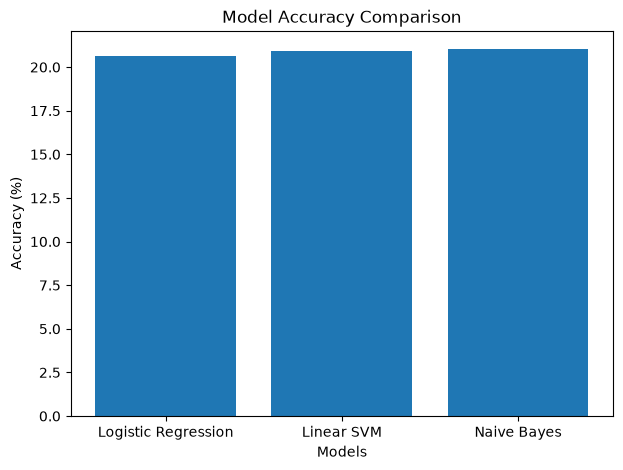

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()

In [23]:
best_model = accuracy_df.loc[
    accuracy_df["Accuracy"].idxmax()
]

print(best_model)

Model       Naive Bayes
Accuracy      21.015348
Name: 2, dtype: object


In [25]:
import joblib

joblib.dump(nb_model, "../models/ticket_classifier.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [26]:
import joblib

model = joblib.load("../models/ticket_classifier.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [27]:
new_ticket = """
I ordered a laptop but received a damaged product.
I need a replacement immediately.
"""

clean_ticket = clean_text(new_ticket)

ticket_vector = vectorizer.transform([clean_ticket])

prediction = model.predict(ticket_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Technical issue


In [28]:
new_ticket = """
My payment was deducted twice from my bank account.
Please refund the extra amount.
"""

clean_ticket = clean_text(new_ticket)

ticket_vector = vectorizer.transform([clean_ticket])

prediction = model.predict(ticket_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Cancellation request


In [29]:
new_ticket = """
My payment was deducted twice from my bank account.
Please refund the extra amount.
"""

clean_ticket = clean_text(new_ticket)

ticket_vector = vectorizer.transform([clean_ticket])

prediction = model.predict(ticket_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Cancellation request


In [30]:
new_ticket = """
I want to cancel my order because it was delivered very late.
"""

clean_ticket = clean_text(new_ticket)

ticket_vector = vectorizer.transform([clean_ticket])

prediction = model.predict(ticket_vector)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Product inquiry


In [31]:
y_pred = model.predict(X_test_vectorized)

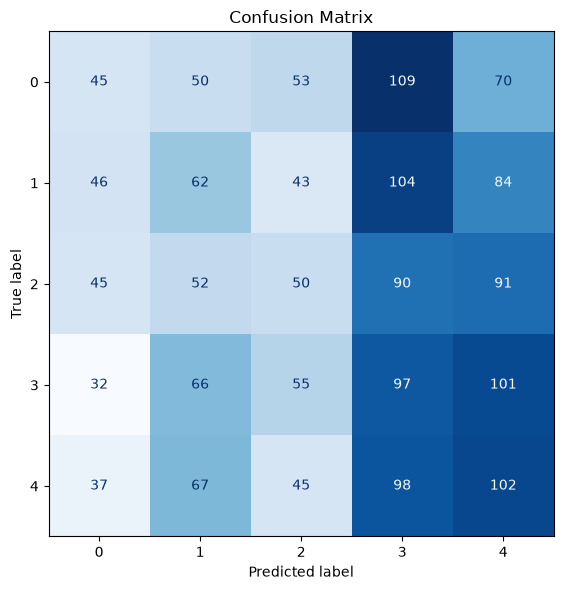

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("../screenshots/confusion_matrix.png", dpi=300)

plt.show()

In [33]:
new_ticket = """
My payment failed but money was deducted from my account.
"""

clean_ticket = clean_text(new_ticket)

ticket_vector = vectorizer.transform([clean_ticket])

prediction = model.predict(ticket_vector)

print("Ticket:")
print(new_ticket)

print("\nPredicted Ticket Type:")
print(prediction[0])

Ticket:

My payment failed but money was deducted from my account.


Predicted Ticket Type:
Billing inquiry


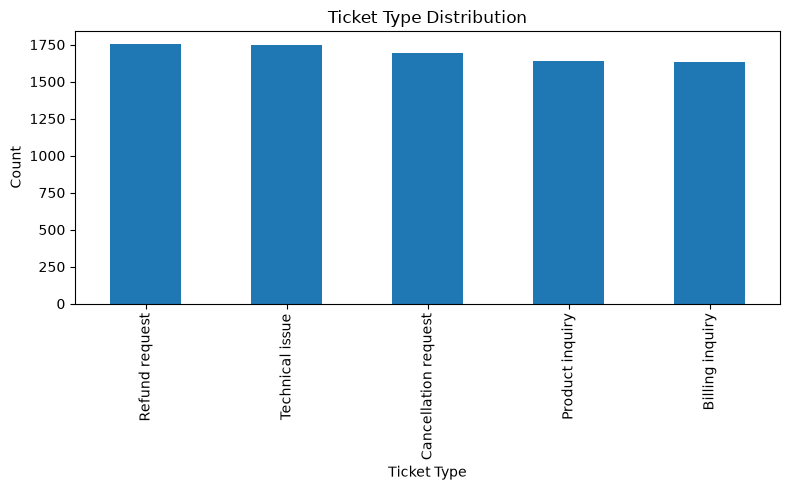

In [34]:
import matplotlib.pyplot as plt

df["Ticket Type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../screenshots/ticket_distribution.png")

plt.show()